In [2]:
# Import initial libraries
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load your modeling dataset from S3
# Replace the path below with your actual S3 path from Day 26
s3 = boto3.client('s3')
bucket_name = 'cmse492-lesurek1-nyc311-339713112540-us-east-1-an' # replace with your bucket name (make sure you have the account regional suffix)
file_name = 'modeling/modeling_data.csv' # make sure to include the path if it's in a folder, e.g. 'modeling/modeling_data.csv'

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (173851, 8)


,agency,borough,problem,incident_zip,day_of_week,hour_of_day,same_day_complaint_volume,days_to_close
0,DCWP,QUEENS,Consumer Complaint,11418.0,6,13,17,1
1,DCWP,BROOKLYN,Consumer Complaint,11220.0,6,9,17,3
2,DCWP,QUEENS,Consumer Complaint,11432.0,6,11,17,1
3,DCWP,BROOKLYN,Consumer Complaint,11203.0,6,22,17,45
4,DCWP,QUEENS,Consumer Complaint,11373.0,6,12,17,1


In [4]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']

Missing values:
agency                          0
borough                         0
problem                         0
incident_zip                 1765
day_of_week                     0
hour_of_day                     0
same_day_complaint_volume       0
days_to_close                   0
dtype: int64

Data types:
agency                        object
borough                       object
problem                       object
incident_zip                 float64
day_of_week                    int64
hour_of_day                    int64
same_day_complaint_volume      int64
days_to_close                  int64
dtype: object


In [5]:
# Define feature columns and target column
# Replace these with your actual column names
feature_cols = ['agency', 'borough', 'incident_zip', 'problem', 'day_of_week','hour_of_day','same_day_complaint_volume']  # <-- update this
target_col = 'days_to_close'

# If your target needs to be binarized or modified in some way, do it here
# Example: df['high_volume'] = (df['volume_quartile'] == 1).astype(int)

X = df[feature_cols]
y = df[target_col]

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Features: ['agency', 'borough', 'incident_zip', 'problem', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']
Target: days_to_close

Target distribution:
days_to_close
0     107909
1      17700
2      12346
3       8184
4       5827
5       4598
6       3137
7       1935
8       1420
9       1255
10       847
11       733
12       697
13       619
14       556
15       499
16       450
17       434
19       392
18       377
20       322
21       286
22       271
23       266
26       231
30       225
25       225
24       215
27       186
29       170
28       169
32       161
31       153
33       137
35       106
36        98
34        97
40        85
38        79
37        76
41        70
39        69
42        53
45        39
43        37
44        34
46        29
48        19
47        16
49        12
Name: count, dtype: int64

Class balance: {0: 0.621, 1: 0.102, 2: 0.071, 3: 0.047, 4: 0.034, 5: 0.026, 6: 0.018, 7: 0.011, 8: 0.008, 9: 0.007, 10: 0.005, 11: 0.004, 12: 0.004

In [6]:
# Import train_test_split for splitting the data
from sklearn.model_selection import train_test_split

# Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  139080 rows
Test set:      34771 rows

Class balance in training set:
days_to_close
0     0.620
1     0.102
2     0.071
3     0.047
4     0.034
5     0.026
6     0.018
7     0.011
8     0.008
9     0.007
10    0.005
11    0.004
12    0.004
13    0.004
14    0.003
15    0.003
16    0.003
17    0.003
18    0.002
19    0.002
20    0.002
21    0.002
22    0.002
23    0.002
26    0.001
30    0.001
25    0.001
24    0.001
27    0.001
28    0.001
29    0.001
32    0.001
31    0.001
33    0.001
35    0.001
34    0.001
36    0.001
38    0.000
40    0.000
39    0.000
37    0.000
41    0.000
42    0.000
45    0.000
44    0.000
43    0.000
46    0.000
48    0.000
49    0.000
47    0.000
Name: proportion, dtype: float64

Class balance in test set:
days_to_close
0     0.624
1     0.101
2     0.070
3     0.046
4     0.032
5     0.026
6     0.018
7     0.013
8     0.008
9     0.007
10    0.005
11    0.004
12    0.004
13    0.003
14    0.003
15    0.003
19    0.003
16    0.002
17    0.00

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical vs. numeric columns automatically
cat_cols = X.select_dtypes(include=['object',]).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns     ({len(num_cols)}): {num_cols}")

# Build the transformer:
#   - OneHotEncoder for categorical columns
#     drop='first'         avoids multicollinearity (k-1 dummies per feature)
#     sparse_output=False  returns a regular numpy array (easier to inspect)
#     handle_unknown='ignore'  silently zeros out categories not seen in training
#   - StandardScaler for numeric columns (optional but often helpful for models like Logistic Regression)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),  # scale numeric columns
    ]
)

# Fit ONLY on training data, then apply to both splits
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)
X_train_enc = np.nan_to_num(X_train_enc)
X_test_enc = np.nan_to_num(X_test_enc)
# Recover feature names for later coefficient inspection
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")

Categorical columns (3): ['agency', 'borough', 'problem']
Numeric columns     (4): ['incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



Encoded feature matrix shape: (139080, 162)
Total features after encoding: 162

First few encoded feature names: ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD']


In [8]:
from sklearn.linear_model import LinearRegression

# Train the linear regression baseline
model = LinearRegression()
model.fit(X_train_enc, y_train)

print("Model trained successfully.")
print("Linear Regression coefficients learned.")

Model trained successfully.
Linear Regression coefficients learned.


In [9]:
# Inspect linear regression coefficients
# After encoding, use encoded_feature_names instead of feature_cols

coef_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': model.coef_
})

# Sort by absolute magnitude to show strongest effects
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("Linear Regression coefficients (top 10 strongest effects):")
print(coef_df[['feature', 'coefficient']].head(10).to_string(index=False))

print("\nInterpretation:")
print("Positive coefficient = increases predicted days_to_close")
print("Negative coefficient = decreases predicted days_to_close")
print("Magnitude = strength of effect (holding other variables constant)")

Linear Regression coefficients (top 10 strongest effects):
                               feature  coefficient
problem_Institution Disposal Complaint    32.064622
       problem_For Hire Vehicle Report    22.838637
            problem_Food Establishment    15.107321
                            agency_OOS    13.941535
             problem_Cannabis Retailer    13.941535
                 problem_Lost Property   -13.803349
          problem_Green Taxi Complaint   -12.338147
             problem_Smoking or Vaping    12.331697
    problem_Beach/Pool/Sauna Complaint    12.185480
          problem_Non-Residential Heat    11.556594

Interpretation:
Positive coefficient = increases predicted days_to_close
Negative coefficient = decreases predicted days_to_close
Magnitude = strength of effect (holding other variables constant)


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on the test set
y_pred = model.predict(X_test_enc)

# Compute regression metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} days")
print(f"RMSE: {rmse:.3f} days")
print(f"R²:   {r2:.3f}")

MAE:  1.885 days
RMSE: 4.129 days
R²:   0.364


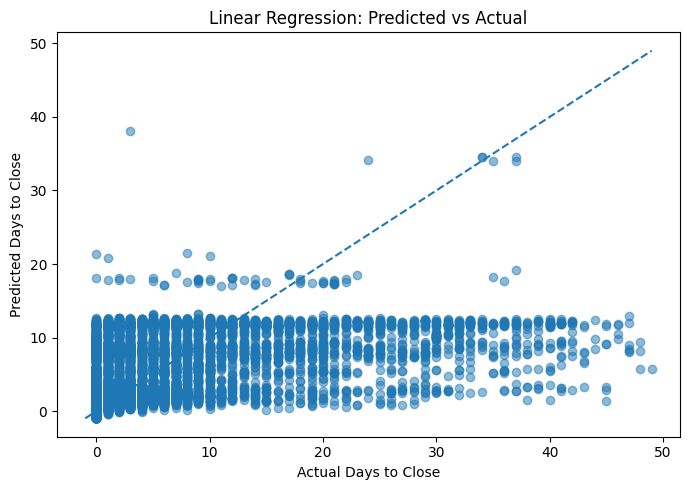

Plot saved to predicted_vs_actual.png
Confusion matrix saved to confusion_matrix.png


In [15]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Days to Close")
plt.ylabel("Predicted Days to Close")
plt.title("Linear Regression: Predicted vs Actual")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=120)
plt.show()

print("Plot saved to predicted_vs_actual.png")
print("Confusion matrix saved to confusion_matrix.png")

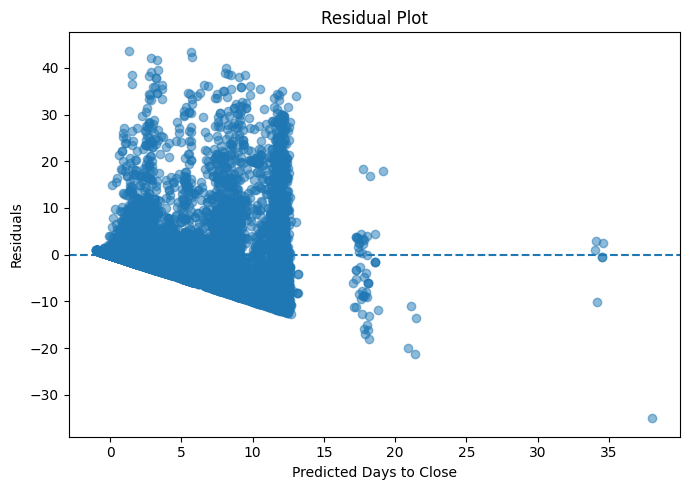

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Days to Close")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()